# Deep Learning Lab 5

# **Name:** NIVASRI T
#**Roll No:** 24BAD081


## Setup: Install & Import Libraries

In [1]:
# Install required libraries
!pip install -q datasets tensorflow numpy matplotlib


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.utils import to_categorical

# Roll No: 24BAD081 | Name: NIVASRI T
STUDENT_NAME = "NIVASRI T"
ROLL_NO = "24BAD081"

np.random.seed(42)
tf.random.set_seed(42)

print("Student:", STUDENT_NAME, "| Roll No:", ROLL_NO)
print("TensorFlow version:", tf.__version__)


Student: NIVASRI T | Roll No: 24BAD081
TensorFlow version: 2.20.0


---
## TASK A: Dataset Preparation


In [3]:
# Roll No: 24BAD081 - Load Tiny Shakespeare dataset from Hugging Face
from datasets import load_dataset

try:
    dataset = load_dataset("tiny_shakespeare")
    raw_text = dataset["train"]["text"][0]
except Exception as e:
    # Fallback: Karpathy's char-rnn tiny shakespeare mirror
    print("Falling back to direct download:", e)
    import urllib.request
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    raw_text = urllib.request.urlopen(url).read().decode("utf-8")

print("Total characters in dataset:", len(raw_text))
print("\nSample text:\n")
print(raw_text[:500])


README.md:   0%|          | 0.00/6.10k [00:00<?, ?B/s]

tiny_shakespeare.py:   0%|          | 0.00/3.73k [00:00<?, ?B/s]

Falling back to direct download: Dataset scripts are no longer supported, but found tiny_shakespeare.py
Total characters in dataset: 1115394

Sample text:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [4]:
# Roll No: 24BAD081 - Explore dataset
lines = raw_text.split("\n")
print("Number of lines:", len(lines))
print("Sample lines:")
for line in lines[100:110]:
    print(line)


Number of lines: 40001
Sample lines:

First Citizen:
We cannot, sir, we are undone already.

MENENIUS:
I tell you, friends, most charitable care
Have the patricians of you. For your wants,
Your suffering in this dearth, you may as well
Strike at the heaven with your staves as lift them
Against the Roman state, whose course will on


In [5]:
# Roll No: 24BAD081 - Convert text to lowercase
text = raw_text.lower()

# Basic cleaning: keep only relevant characters, collapse whitespace
text = re.sub(r"[^a-z0-9\s.,;:!?']", " ", text)
text = re.sub(r"\s+", " ", text).strip()

# For faster training in a lab setting, use a manageable subset of the corpus
text = text[:200000]

print("Length of processed text:", len(text))
print(text[:500])


Length of processed text: 200000
first citizen: before we proceed any further, hear me speak. all: speak, speak. first citizen: you are all resolved rather to die than to famish? all: resolved. resolved. first citizen: first, you know caius marcius is chief enemy to the people. all: we know't, we know't. first citizen: let us kill him, and we'll have corn at our own price. is't a verdict? all: no more talking on't; let it be done: away, away! second citizen: one word, good citizens. first citizen: we are accounted poor citizens


In [6]:
# Roll No: 24BAD081 - Tokenize text into words and build vocabulary
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

word_index = tokenizer.word_index
vocab_size = len(word_index) + 1  # +1 for padding token (index 0)

print("Vocabulary size:", vocab_size)
print("Sample word -> index mapping:")
for word, idx in list(word_index.items())[:10]:
    print(f"  {word}: {idx}")


Vocabulary size: 4912
Sample word -> index mapping:
  the: 1
  and: 2
  to: 3
  you: 4
  i: 5
  of: 6
  a: 7
  that: 8
  in: 9
  he: 10


In [7]:
# Roll No: 24BAD081 - Generate input sequences for next-word prediction
token_list = tokenizer.texts_to_sequences([text])[0]
print("Total tokens:", len(token_list))

SEQ_LENGTH = 6  # number of previous words used to predict the next word
sequences = []
for i in range(SEQ_LENGTH, len(token_list)):
    seq = token_list[i - SEQ_LENGTH:i + 1]  # SEQ_LENGTH input words + 1 target word
    sequences.append(seq)

sequences = np.array(sequences)
print("Total sequences generated:", len(sequences))
print("Sample sequence:", sequences[0])


Total tokens: 36411
Total sequences generated: 36405
Sample sequence: [ 38  82 114  25 561 193 277]


In [8]:
# Roll No: 24BAD081 - Apply sequence padding (sequences already fixed length,
# pad_sequences used to demonstrate/ensure uniform length as required by the procedure)
sequences = pad_sequences(sequences, maxlen=SEQ_LENGTH + 1, padding='pre')

X = sequences[:, :-1]   # input words
y = sequences[:, -1]    # target (next) word

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (36405, 6)
y shape: (36405,)


In [9]:
# Roll No: 24BAD081 - Train/validation split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])


Training samples: 29124
Validation samples: 7281


---
## TASK B: Implementing the RNN Model


In [10]:
# Roll No: 24BAD081 - Build the RNN model
EMBEDDING_DIM = 64
RNN_UNITS = 128

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=SEQ_LENGTH),
    SimpleRNN(RNN_UNITS, return_sequences=False),
    Dense(vocab_size, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

---
## TASK C: RNN Model Training and Performance Evaluation



In [11]:
# Roll No: 24BAD081 - Train the model
EPOCHS = 20
BATCH_SIZE = 128

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - accuracy: 0.0322 - loss: 6.9199 - val_accuracy: 0.0343 - val_loss: 6.7431
Epoch 2/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.0383 - loss: 6.4289 - val_accuracy: 0.0419 - val_loss: 6.7323
Epoch 3/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.0450 - loss: 6.2337 - val_accuracy: 0.0423 - val_loss: 6.7604
Epoch 4/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.0466 - loss: 6.0783 - val_accuracy: 0.0426 - val_loss: 6.8056
Epoch 5/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.0512 - loss: 5.9721 - val_accuracy: 0.0427 - val_loss: 6.8057
Epoch 6/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.0537 - loss: 5.8643 - val_accuracy: 0.0456 - val_loss: 6.8409
Epoch 7/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.0573 - loss: 5.7553 - val_accuracy: 0.0503 - val_loss: 6.8725
Epoch 8/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.0644 - loss: 5.5981 - 

In [12]:
# Roll No: 24BAD081 - Record final training/validation metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy   : {final_train_acc:.4f}")
print(f"Final Validation Accuracy : {final_val_acc:.4f}")
print(f"Final Training Loss       : {final_train_loss:.4f}")
print(f"Final Validation Loss     : {final_val_loss:.4f}")


Final Training Accuracy   : 0.2364
Final Validation Accuracy : 0.0510
Final Training Loss       : 3.9573
Final Validation Loss     : 7.5265


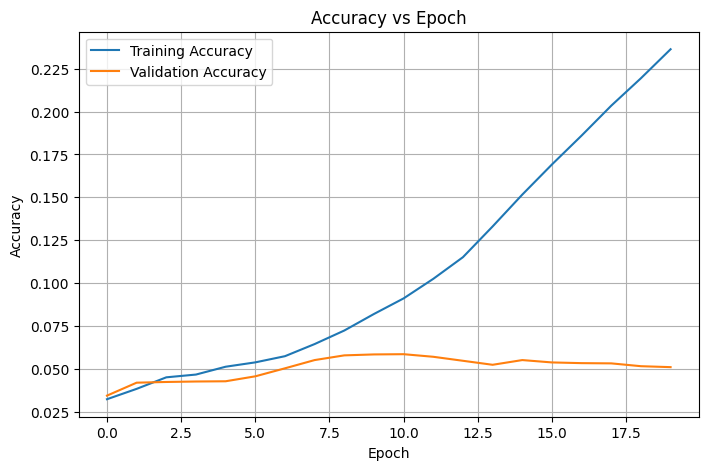

In [13]:
# Roll No: 24BAD081 - Visualize Accuracy vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


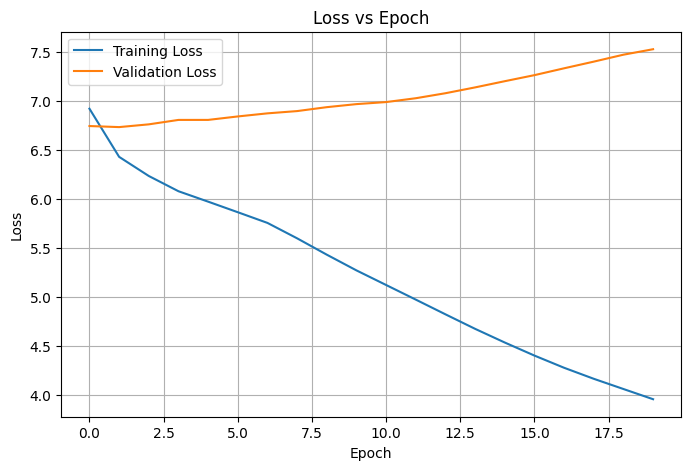

In [14]:
# Roll No: 24BAD081 - Visualize Loss vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


---
## TASK D: Deep Learning Experiment Management (Text Generation)


In [15]:
# Roll No: 24BAD081 - Text generation function
def generate_text(seed_text, next_words=30, seq_length=SEQ_LENGTH):
    result = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=seq_length, padding='pre')
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(predicted_probs, axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        if output_word == "":
            break

        result += " " + output_word
    return result


In [16]:
# Roll No: 24BAD081 - Generate text using multiple seed inputs
seed_inputs = [
    "to be or not to",
    "thou art a",
    "shall i compare",
    "friends romans countrymen"
]

generated_samples = {}
for seed in seed_inputs:
    generated = generate_text(seed, next_words=25)
    generated_samples[seed] = generated
    print(f"Seed: \"{seed}\"")
    print(f"Generated: {generated}")
    print("-" * 80)


Seed: "to be or not to"
Generated: to be or not to the osprey of the people that i am procured without their bloody will haste to give the hopeful was a dearest patricians of the volscian
--------------------------------------------------------------------------------
Seed: "thou art a"
Generated: thou art a kind of the bottom of the opinion is the patricians of the whole part of the state of the patricians of the world of his
--------------------------------------------------------------------------------
Seed: "shall i compare"
Generated: shall i compare am not to the world of his sword and godded didst and the tables of the town that he is not bold i am wont
--------------------------------------------------------------------------------
Seed: "friends romans countrymen"
Generated: friends romans countrymen the sword of his country of the tower of the whole gods 'tis a friends that dropp'd the other of freedom and you are not
---------------------------------------------------------